In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os
import ipywidgets as widgets
from IPython.display import display
import plotly.graph_objects as go
import plotly.io as pio
from matplotlib.widgets import Slider
import ipywidgets as widgets
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import matplotlib.ticker as ticker

import seaborn as sns
from shapely.geometry import Point, Polygon as ShapelyPolygon

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import imageio

import cmocean
import cmocean.cm as cmo
import importlib
import utils  # Importing the utils module

In [2]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np


In [3]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

locations = utils.locations
location_labels = {key: value['label_short'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

In [4]:
hypothesis_order

{'h_null': 0, 'h_ice': 1, 'h_dvm': 2, 'h_size': 3}

In [5]:
location_order

{'BS': 0, 'GERL': 1, 'GP': 2, 'MB2': 3}

In [6]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
processed_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/processed_data/'
fig_path = repo_path + 'figures/'
tab_path = repo_path + 'figures/tables/'

In [7]:
summary_file = 'nursery_use_summary.csv'
start_file = 'IDLloc_spawning_21dfilter.csv'
traj_file = 'processed_trajectories_21dfilter.csv'

summary=pd.read_csv(processed_path + summary_file) 

starting_location_df=pd.read_csv(processed_path + start_file) 

df_traj=pd.read_csv(processed_path + traj_file)

In [8]:
# Look at and summarize data:

In [9]:
# Create a summary of the number of unique larval_id's for each hypothesis, start year, and IDL_loc
summary_df = df_traj.groupby(['hypothesis', 'start_year', 'IDL_loc'])['larval_id'].nunique().reset_index()

# Rename the column for clarity
summary_df.rename(columns={'larval_id': 'unique_larval_count'}, inplace=True)

summary_df.head()

,hypothesis,start_year,IDL_loc,unique_larval_count
0,h_dvm,2016,BS,290
1,h_dvm,2016,GERL,45
2,h_dvm,2016,GP,66
3,h_dvm,2016,MB2,60
4,h_dvm,2017,BS,184


In [10]:
# Extract Summary Information
critical_columns = ['larval_id', 'date', 'lon', 'lat', 'hypothesis', 'start_year', 'IDL_loc', 'stage']
presence_columns = ['BS', 'GERL', 'GP', 'MB2','outside']

# Function to create the starting location DataFrame
def create_starting_location_df(df):
    t0_data = df[df['T'] == 0].copy()
    starting_locations = t0_data[critical_columns+presence_columns].copy()  # Use copy() to avoid SettingWithCopyWarning
    starting_locations.rename(columns={'date': 'release_date', 'lat': 'release_lat', 'lon': 'release_lon'}, inplace=True)
    return starting_locations

In [11]:
# Create the starting location DataFrame
starting_location_df = create_starting_location_df(df_traj)

# Check It
print('number of larvae:', starting_location_df.larval_id.nunique())
# presence_summary_starting_location = summarize_presence(starting_location_df)
starting_location_df.head()

number of larvae: 11487


,larval_id,release_date,release_lon,release_lat,hypothesis,start_year,IDL_loc,stage,BS,GERL,GP,MB2,outside
0,00_16_1_0003,2016-11-01,298.26752,-63.602314,h_null,2016,BS,0,True,False,False,False,False
180,00_16_1_0004,2016-11-01,298.70044,-63.499004,h_null,2016,BS,0,True,False,False,False,False
360,00_16_1_0005,2016-11-01,298.89746,-63.201790,h_null,2016,BS,0,True,False,False,False,False
540,00_16_1_0006,2016-11-01,299.32642,-63.093323,h_null,2016,BS,0,True,False,False,False,False
720,00_16_1_0007,2016-11-01,299.74160,-62.983440,h_null,2016,BS,0,True,False,False,False,False


## Matrix

In [13]:
# Step 1: Data Processing Function
# Process the data to compute the connectivity matrix for a given hypothesis.
def compute_connectivity_matrix(df, hypothesis):
    # Filter data for the given hypothesis
    hypothesis_data = df[df['hypothesis'] == hypothesis]

    # Extract starting locations
    starting_locations = create_starting_location_df(hypothesis_data)
    traj_with_start = hypothesis_data.merge(
        starting_locations[['larval_id', 'IDL_loc']],
        on='larval_id',
        suffixes=('', '_source')
    )

    # Identify destination regions
    traj_with_start['destination'] = traj_with_start[['BS', 'GERL', 'GP', 'MB2']].idxmax(axis=1)

    # Summarize yearly connectivity
    connectivity_counts = traj_with_start.groupby(['IDL_loc_source', 'destination', 'start_year']).size().reset_index(name='count')
    connectivity_counts['presence'] = connectivity_counts['count'] > 0

    yearly_connectivity = connectivity_counts.groupby(['IDL_loc_source', 'destination'])['presence'].sum().reset_index()
    yearly_connectivity.rename(columns={'presence': 'years_connected'}, inplace=True)

    # Pivot to create the connectivity matrix
    connectivity_matrix = yearly_connectivity.pivot(
        index='destination',
        columns='IDL_loc_source',
        values='years_connected'
    ).fillna(0)
    
    return connectivity_matrix

In [14]:
def plot_all_hypotheses_grid_anno(hypotheses_dict, locations_dict, df, save_path=None):

    # Extract relevant dictionaries
    hypotheses_name = {key: value['name'] for key, value in hypotheses_dict.items()}
    hypotheses_labels = {key: value['label'] for key, value in hypotheses_dict.items()}
    hypotheses_order = {key: value['order'] for key, value in hypotheses_dict.items()}
    location_labels = {key: value['label_short'] for key, value in locations_dict.items()}
    location_order = {key: value['order'] for key, value in locations_dict.items()}

    # Sort hypotheses by order
    sorted_hypotheses = sorted(hypotheses_name.keys(), key=lambda x: hypotheses_order[x])


    # Update font sizes globally for better scaling
    plt.rcParams.update({
        'font.size': 18,       # General font size
        'axes.titlesize': 14,  # Titles for individual plots
        'axes.labelsize': 16,  # Axis labels
        'xtick.labelsize': 14, # X-tick labels
        'ytick.labelsize': 14  # Y-tick labels
    })

    # Define discrete colormap
    cmap = mcolors.ListedColormap(['aliceblue', 'lightblue', 'blue', 'darkblue'])
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create a figure with a 2x2 grid and adjust layout
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
    axes = axes.flatten()

    for i, hypothesis in enumerate(sorted_hypotheses):
        # Compute connectivity matrix
        connectivity_matrix = compute_connectivity_matrix(df, hypothesis)

        # Reorder rows/columns based on location order
        location_keys = sorted(location_labels.keys(), key=lambda x: location_order[x])
        connectivity_matrix = connectivity_matrix.reindex(index=location_keys, columns=location_keys, fill_value=0)

        # Mask upper triangle
        mask = np.triu(np.ones_like(connectivity_matrix, dtype=bool))

        # Plot on the respective subplot
        sns.heatmap(
            connectivity_matrix,
            annot=True,
            fmt=".0f",
            cmap=cmap,
            norm=norm,
            linewidths=.5,
            mask=mask,
            ax=axes[i],
            cbar=False,  # Disable individual color bars
            annot_kws={'fontsize': 14},  # Adjust annotation font size
        )

        # Add annotation in the top right of each plot
        annotation_text = f"{hypotheses_labels[hypothesis]} Simulation"
        axes[i].annotate(
            annotation_text,
            xy=(0.975, 0.925), xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='right', va='bottom',
            bbox=dict(boxstyle="round, pad=0.3", edgecolor='white', facecolor='white')
        )

        # Add axis labels only where necessary
        if i % 2 == 0:  # First column: Keep Y-axis labels
            axes[i].set_ylabel('Destination Region', fontsize=16)
            axes[i].set_yticklabels([location_labels[loc] for loc in connectivity_matrix.index], rotation=30)
        else:  # Second column: Remove Y-axis labels
            axes[i].set_ylabel('')
            axes[i].set_yticklabels([])

        if i >= 2:  # Second row: Keep X-axis labels
            axes[i].set_xlabel('Source Region', fontsize=16)
            axes[i].set_xticklabels([location_labels[loc] for loc in connectivity_matrix.columns], rotation=-30)
        else:  # First row: Remove X-axis labels
            axes[i].set_xlabel('')
            axes[i].set_xticklabels([])

        # Add a box around the plot
        rect = patches.Rectangle(
            (0, 0), 1, 1, transform=axes[i].transAxes,
            color='black', linewidth=2, fill=False
        )
        axes[i].add_patch(rect)

    # Add a shared color bar
    cbar_ax = fig.add_axes([1.02, 0.25, 0.02, 0.5])  # Adjust position of the shared color bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=[0, 1, 2, 3], label='Years with Connectivity (out of 3)')

    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

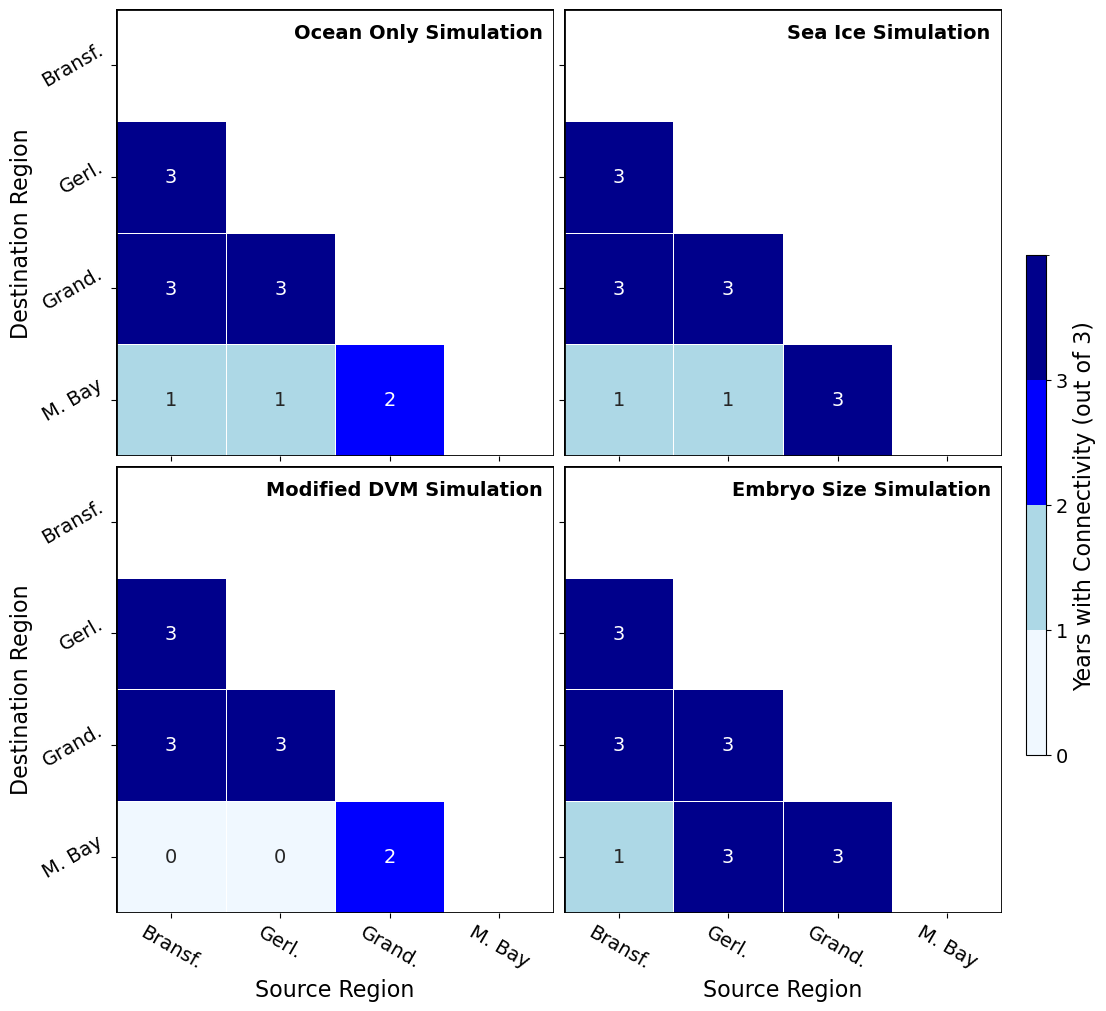

In [15]:
plot_all_hypotheses_grid_anno(
    hypotheses, 
    locations, 
    df_traj, 
    # save_path=fig_path+'connectivity_grid_2x2.png'
)

# Matrix Connections

In [12]:
# Step 1: Data Processing Function
# Process the data to compute the connectivity matrix for a given hypothesis.
def compute_connectivity_matrix(df, hypothesis):
    # Filter data for the given hypothesis
    hypothesis_data = df[df['hypothesis'] == hypothesis]

    # Extract starting locations
    starting_locations = create_starting_location_df(hypothesis_data)
    traj_with_start = hypothesis_data.merge(
        starting_locations[['larval_id', 'IDL_loc']],
        on='larval_id',
        suffixes=('', '_source')
    )

    # Identify destination regions
    traj_with_start['destination'] = traj_with_start[['BS', 'GERL', 'GP', 'MB2']].idxmax(axis=1)

    # Summarize yearly connectivity
    connectivity_counts = traj_with_start.groupby(['IDL_loc_source', 'destination', 'start_year']).size().reset_index(name='count')
    connectivity_counts['presence'] = connectivity_counts['count'] > 0

    yearly_connectivity = connectivity_counts.groupby(['IDL_loc_source', 'destination'])['presence'].sum().reset_index()
    yearly_connectivity.rename(columns={'presence': 'years_connected'}, inplace=True)

    # Pivot to create the connectivity matrix
    connectivity_matrix = yearly_connectivity.pivot(
        index='destination',
        columns='IDL_loc_source',
        values='years_connected'
    ).fillna(0)
    
    return connectivity_matrix

In [13]:
# Step 2: Plotting Function
# Plot the connectivity matrix with the discrete colormap.

def plot_connectivity_matrix(matrix, hypothesis):
    import matplotlib.colors as mcolors
    
    # Define discrete colormap
    cmap = mcolors.ListedColormap(['white', 'lightblue', 'blue', 'darkblue'])
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Mask upper triangle
    mask = np.triu(np.ones_like(matrix, dtype=bool))

    # Plot the matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".0f",
        cmap=cmap,
        norm=norm,
        linewidths=.5,
        mask=mask,
        cbar_kws={
            'boundaries': bounds,
            'ticks': [0, 1, 2, 3],
            'label': 'Years with Connectivity'
        }
    )
    plt.title(f'Connectivity Matrix (Years with Connectivity) - {hypothesis}')
    plt.xlabel('Source Region')
    plt.ylabel('Destination Region')
    plt.show()

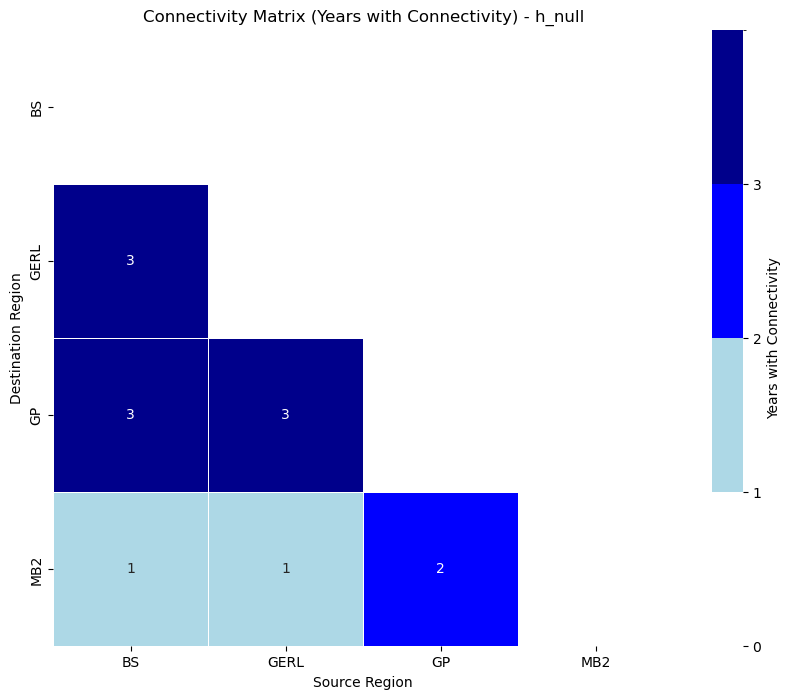

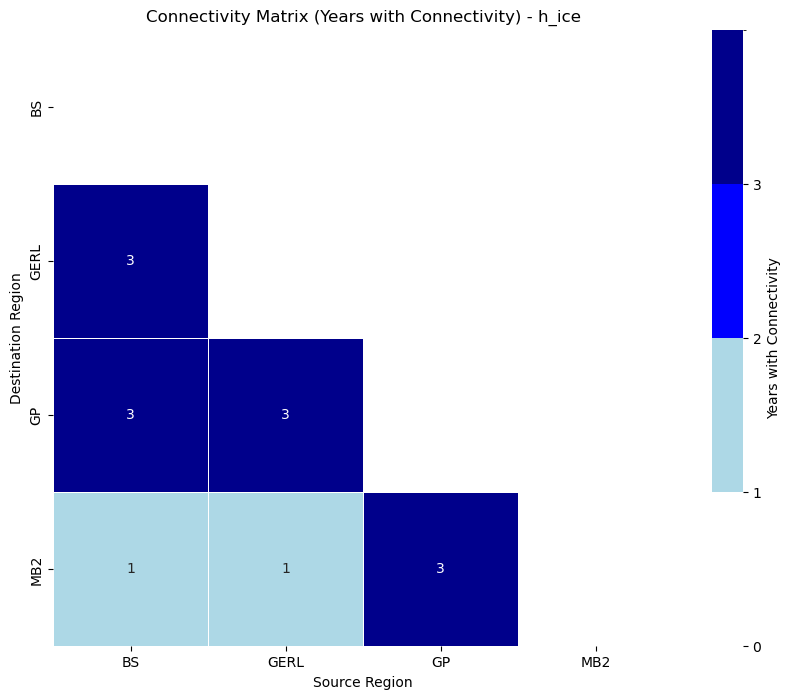

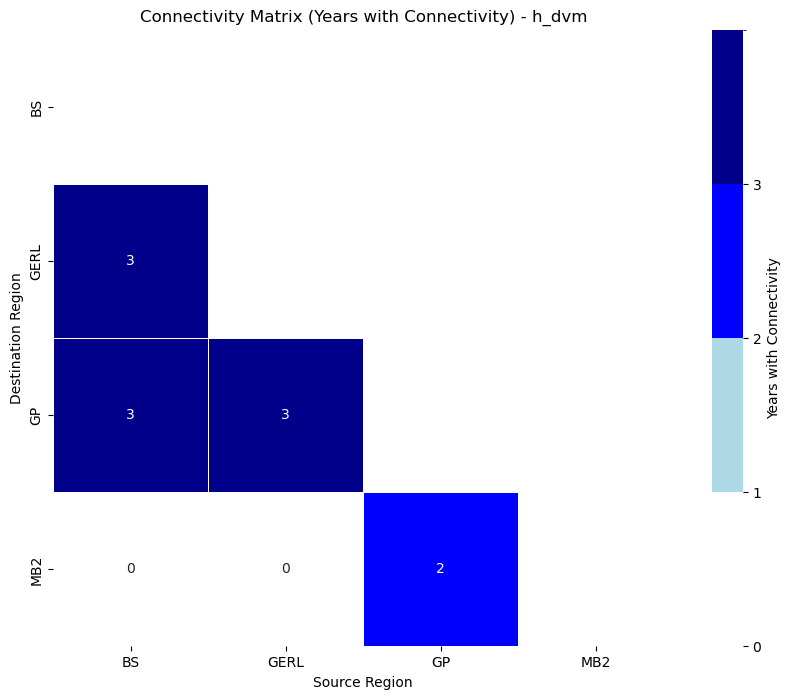

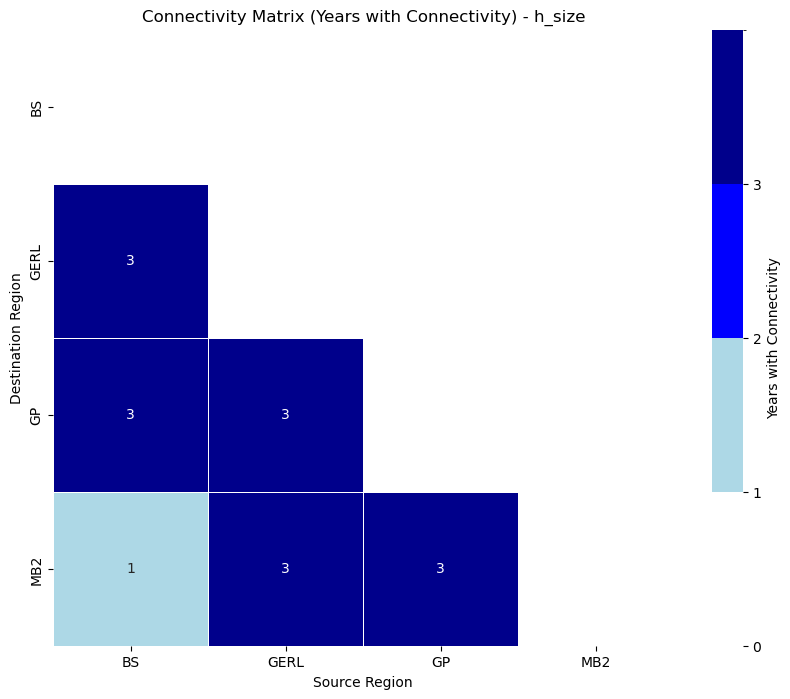

In [14]:
# Step 3: Main Workflow
# Call these functions for each hypothesis.

# Get unique hypotheses
hypotheses = df_traj['hypothesis'].unique()

# Process and plot for each hypothesis
for hypothesis in hypotheses:
    connectivity_matrix = compute_connectivity_matrix(df_traj, hypothesis)
    plot_connectivity_matrix(connectivity_matrix, hypothesis)

# Quad Plot

In [12]:
def plot_all_hypotheses_grid_with_labels(hypotheses_dict, locations_dict, df):

    # Sort hypotheses by order
    sorted_hypotheses = sorted(hypotheses_name.keys(), key=lambda x: hypotheses_order[x])

    # Define discrete colormap
    cmap = mcolors.ListedColormap(['white', 'lightblue', 'blue', 'darkblue'])
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create a figure with a 2x2 grid and constrained layout
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)
    axes = axes.flatten()

    for i, hypothesis in enumerate(sorted_hypotheses):
        # Compute connectivity matrix
        connectivity_matrix = compute_connectivity_matrix(df, hypothesis)

        # Reorder rows/columns based on location order
        location_keys = sorted(location_labels.keys(), key=lambda x: location_order[x])
        connectivity_matrix = connectivity_matrix.reindex(index=location_keys, columns=location_keys, fill_value=0)

        # Mask upper triangle
        mask = np.triu(np.ones_like(connectivity_matrix, dtype=bool))

        # Plot on the respective subplot
        sns.heatmap(
            connectivity_matrix,
            annot=True,
            fmt=".0f",
            cmap=cmap,
            norm=norm,
            linewidths=.5,
            mask=mask,
            ax=axes[i],
            cbar=False,  # Disable individual color bars
            annot_kws={'fontsize': 10},  # Adjust annotation font size
        )
        axes[i].set_title(f"Advection Simulation: {hypotheses_labels[hypothesis]}", fontsize=16, fontweight='bold')

        # Add axis labels only where necessary
        if i % 2 == 0:  # First column: Keep Y-axis labels
            axes[i].set_ylabel('Destination Region', fontsize=12)
            axes[i].set_yticklabels([location_labels[loc] for loc in connectivity_matrix.index], rotation=30)
        else:  # Second column: Remove Y-axis labels
            axes[i].set_ylabel('')
            axes[i].set_yticklabels([])

        if i >= 2:  # Second row: Keep X-axis labels
            axes[i].set_xlabel('Source Region', fontsize=12)
            axes[i].set_xticklabels([location_labels[loc] for loc in connectivity_matrix.columns], rotation=-30)
        else:  # First row: Remove X-axis labels
            axes[i].set_xlabel('')
            axes[i].set_xticklabels([])

        # Add a box around the plot
        rect = patches.Rectangle(
            (0, 0), 1, 1, transform=axes[i].transAxes,
            color='black', linewidth=2, fill=False
        )
        axes[i].add_patch(rect)

    # Add a shared color bar
    cbar_ax = fig.add_axes([1, 0.25, 0.02, 0.5])  # Position of the shared color bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=[0, 1, 2, 3], label='Years with Connectivity (out of 3)')

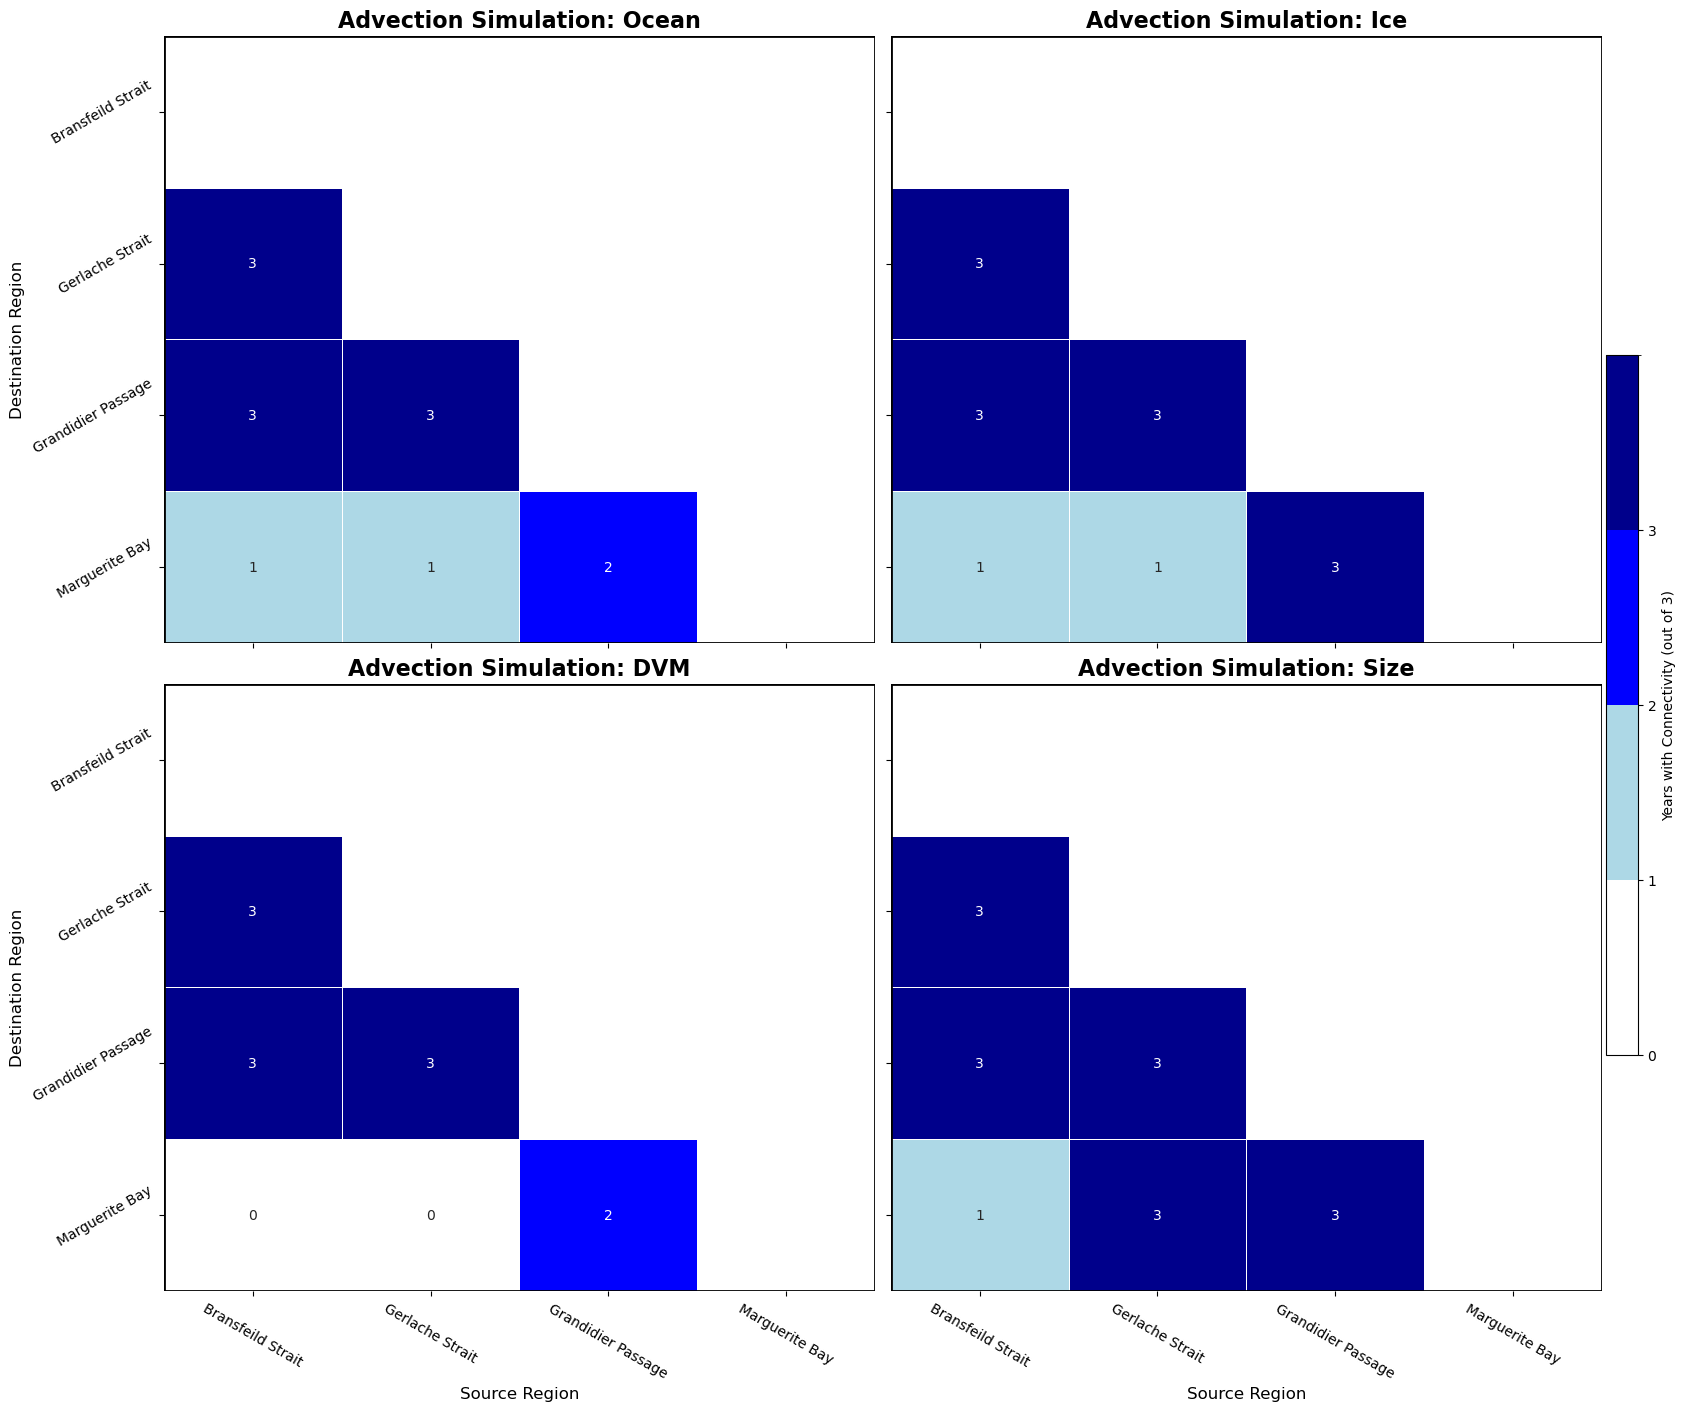

In [13]:
plot_all_hypotheses_grid_with_labels(utils.hypotheses, utils.locations, df_traj)

# No TItle

In [15]:
def plot_all_hypotheses_grid_anno(hypotheses_dict, locations_dict, df, save_path=None):

    # Sort hypotheses by order
    sorted_hypotheses = sorted(hypotheses_name.keys(), key=lambda x: hypotheses_order[x])

    # Define discrete colormap
    cmap = mcolors.ListedColormap(['aliceblue', 'lightblue', 'blue', 'darkblue'])
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create a figure with a 2x2 grid and constrained layout
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), constrained_layout=True)
    axes = axes.flatten()

    for i, hypothesis in enumerate(sorted_hypotheses):
        # Compute connectivity matrix
        connectivity_matrix = compute_connectivity_matrix(df, hypothesis)

        # Reorder rows/columns based on location order
        location_keys = sorted(location_labels.keys(), key=lambda x: location_order[x])
        connectivity_matrix = connectivity_matrix.reindex(index=location_keys, columns=location_keys, fill_value=0)

        # Mask upper triangle
        mask = np.triu(np.ones_like(connectivity_matrix, dtype=bool))

        # Plot on the respective subplot
        sns.heatmap(
            connectivity_matrix,
            annot=True,
            fmt=".0f",
            cmap=cmap,
            norm=norm,
            linewidths=.5,
            mask=mask,
            ax=axes[i],
            cbar=False,  # Disable individual color bars
            annot_kws={'fontsize': 10},  # Adjust annotation font size
        )

        # Add annotation in the top right of each plot
        annotation_text = f"{hypotheses_labels[hypothesis]} Advection Simulation"
        axes[i].annotate(
            annotation_text,
            xy=(0.975, 0.95), xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='right', va='bottom',
            bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='white')
        )

        # Add axis labels only where necessary
        if i % 2 == 0:  # First column: Keep Y-axis labels
            axes[i].set_ylabel('Destination Region', fontsize=12)
            axes[i].set_yticklabels([location_labels[loc] for loc in connectivity_matrix.index], rotation=30)
        else:  # Second column: Remove Y-axis labels
            axes[i].set_ylabel('')
            axes[i].set_yticklabels([])

        if i >= 2:  # Second row: Keep X-axis labels
            axes[i].set_xlabel('Source Region', fontsize=12)
            axes[i].set_xticklabels([location_labels[loc] for loc in connectivity_matrix.columns], rotation=-30)
        else:  # First row: Remove X-axis labels
            axes[i].set_xlabel('')
            axes[i].set_xticklabels([])

        # Add a box around the plot
        rect = patches.Rectangle(
            (0, 0), 1, 1, transform=axes[i].transAxes,
            color='black', linewidth=2, fill=False
        )
        axes[i].add_patch(rect)

    # Add a shared color bar
    cbar_ax = fig.add_axes([1, 0.25, 0.02, 0.5])  # Position of the shared color bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=[0, 1, 2, 3], label='Years with Connectivity (out of 3)')

    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

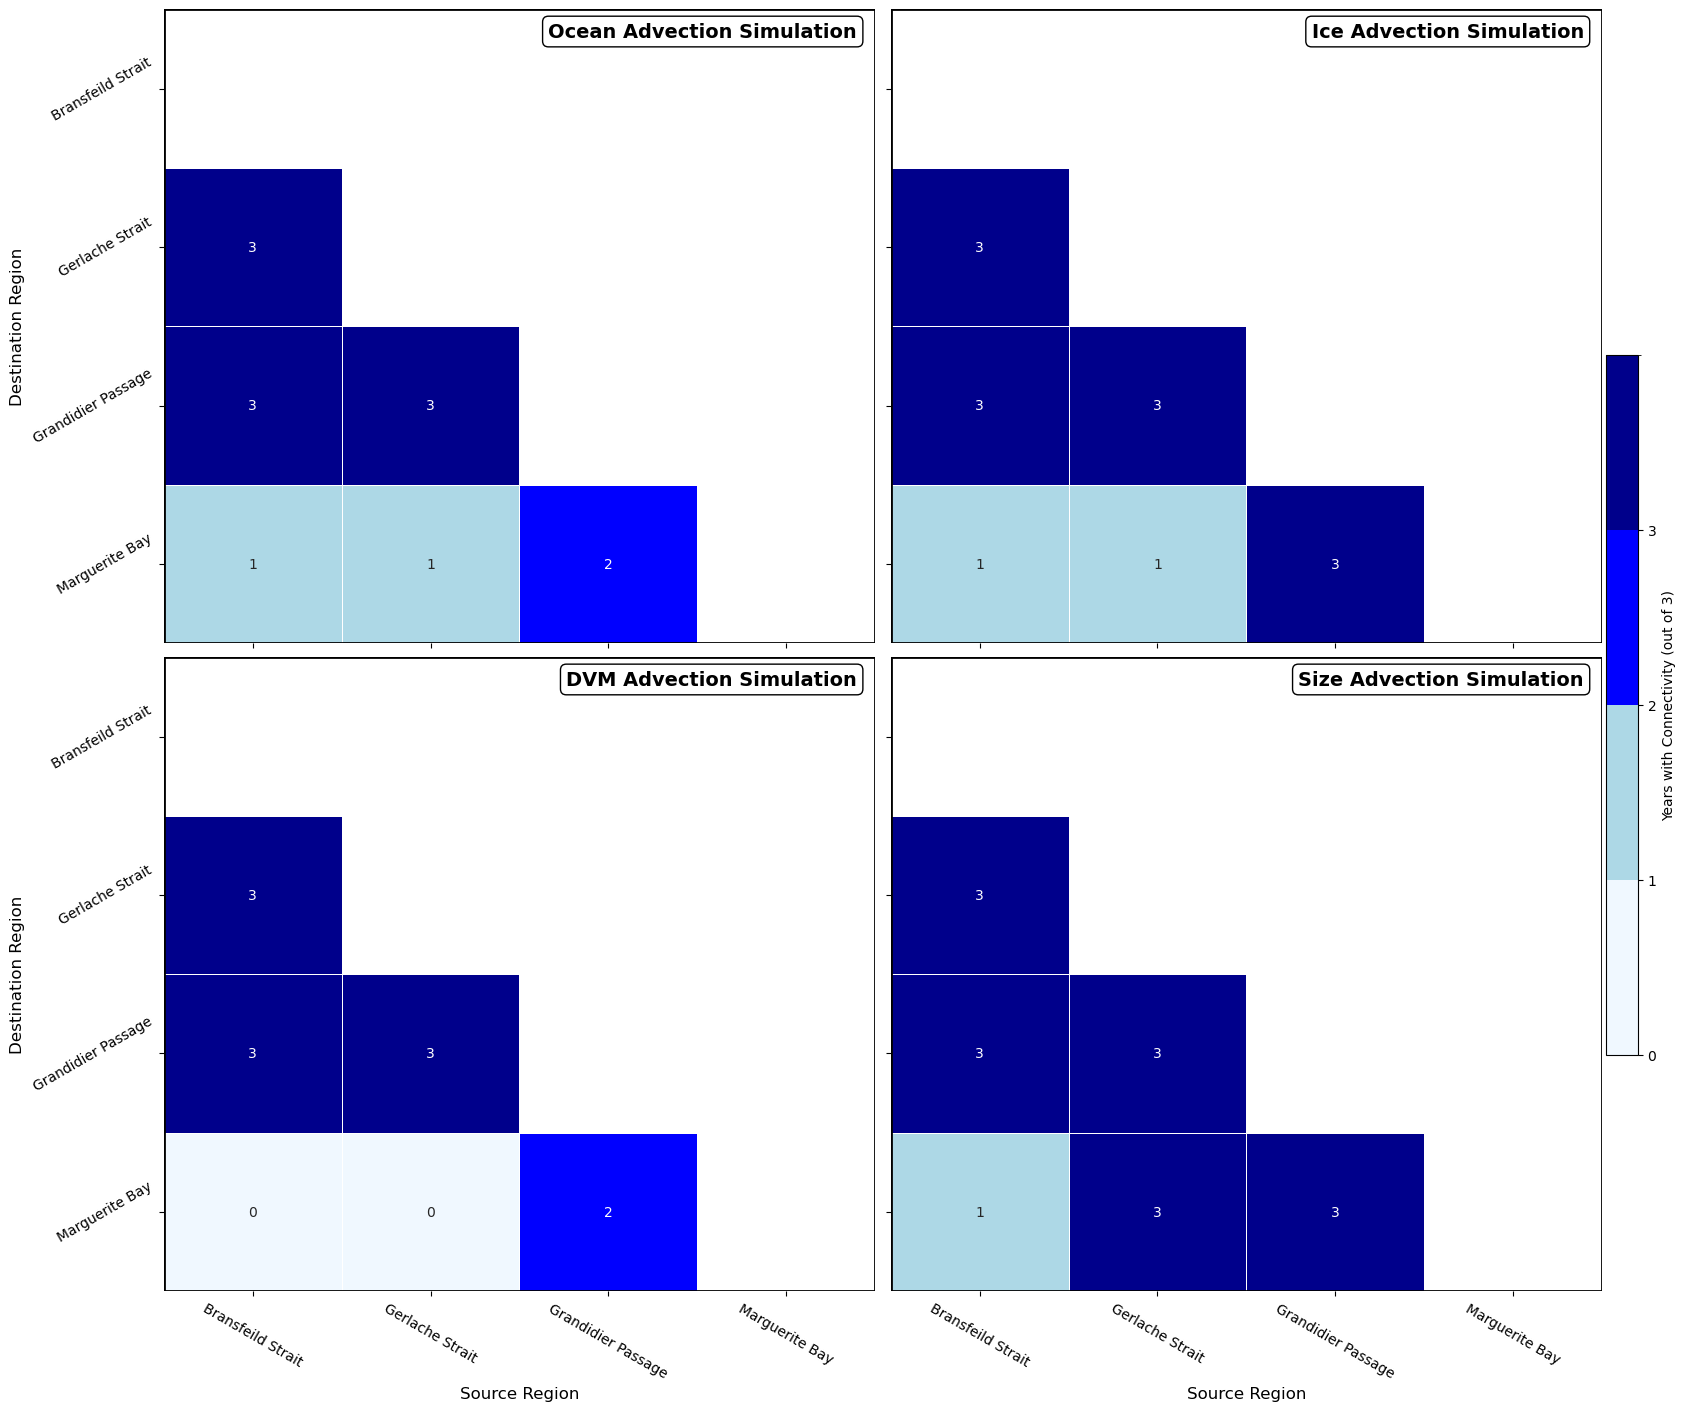

In [16]:
plot_all_hypotheses_grid_anno(
    utils.hypotheses, 
    utils.locations, 
    df_traj, 
    save_path=fig_path+'connectivity_grid.png'
)

In [50]:
def plot_all_hypotheses_grid_anno(hypotheses_dict, locations_dict, df, save_path=None):

    # Extract relevant dictionaries
    hypotheses_name = {key: value['name'] for key, value in hypotheses_dict.items()}
    hypotheses_labels = {key: value['label'] for key, value in hypotheses_dict.items()}
    hypotheses_order = {key: value['order'] for key, value in hypotheses_dict.items()}
    location_labels = {key: value['label_short'] for key, value in locations_dict.items()}
    location_order = {key: value['order'] for key, value in locations_dict.items()}

    # Sort hypotheses by order
    sorted_hypotheses = sorted(hypotheses_name.keys(), key=lambda x: hypotheses_order[x])


    # Update font sizes globally for better scaling
    plt.rcParams.update({
        'font.size': 18,       # General font size
        'axes.titlesize': 14,  # Titles for individual plots
        'axes.labelsize': 16,  # Axis labels
        'xtick.labelsize': 14, # X-tick labels
        'ytick.labelsize': 14  # Y-tick labels
    })

    # Define discrete colormap
    cmap = mcolors.ListedColormap(['aliceblue', 'lightblue', 'blue', 'darkblue'])
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create a figure with a 2x2 grid and adjust layout
    fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
    axes = axes.flatten()

    for i, hypothesis in enumerate(sorted_hypotheses):
        # Compute connectivity matrix
        connectivity_matrix = compute_connectivity_matrix(df, hypothesis)

        # Reorder rows/columns based on location order
        location_keys = sorted(location_labels.keys(), key=lambda x: location_order[x])
        connectivity_matrix = connectivity_matrix.reindex(index=location_keys, columns=location_keys, fill_value=0)

        # Mask upper triangle
        mask = np.triu(np.ones_like(connectivity_matrix, dtype=bool))

        # Plot on the respective subplot
        sns.heatmap(
            connectivity_matrix,
            annot=True,
            fmt=".0f",
            cmap=cmap,
            norm=norm,
            linewidths=.5,
            mask=mask,
            ax=axes[i],
            cbar=False,  # Disable individual color bars
            annot_kws={'fontsize': 14},  # Adjust annotation font size
        )

        # Add annotation in the top right of each plot
        annotation_text = f"{hypotheses_labels[hypothesis]} Simulation"
        axes[i].annotate(
            annotation_text,
            xy=(0.975, 0.925), xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='right', va='bottom',
            bbox=dict(boxstyle="round, pad=0.3", edgecolor='white', facecolor='white')
        )

        # Add axis labels only where necessary
        if i % 2 == 0:  # First column: Keep Y-axis labels
            axes[i].set_ylabel('Destination Region', fontsize=16)
            axes[i].set_yticklabels([location_labels[loc] for loc in connectivity_matrix.index], rotation=30)
        else:  # Second column: Remove Y-axis labels
            axes[i].set_ylabel('')
            axes[i].set_yticklabels([])

        if i >= 2:  # Second row: Keep X-axis labels
            axes[i].set_xlabel('Source Region', fontsize=16)
            axes[i].set_xticklabels([location_labels[loc] for loc in connectivity_matrix.columns], rotation=-30)
        else:  # First row: Remove X-axis labels
            axes[i].set_xlabel('')
            axes[i].set_xticklabels([])

        # Add a box around the plot
        rect = patches.Rectangle(
            (0, 0), 1, 1, transform=axes[i].transAxes,
            color='black', linewidth=2, fill=False
        )
        axes[i].add_patch(rect)

    # Add a shared color bar
    cbar_ax = fig.add_axes([1.02, 0.25, 0.02, 0.5])  # Adjust position of the shared color bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=[0, 1, 2, 3], label='Years with Connectivity (out of 3)')

    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

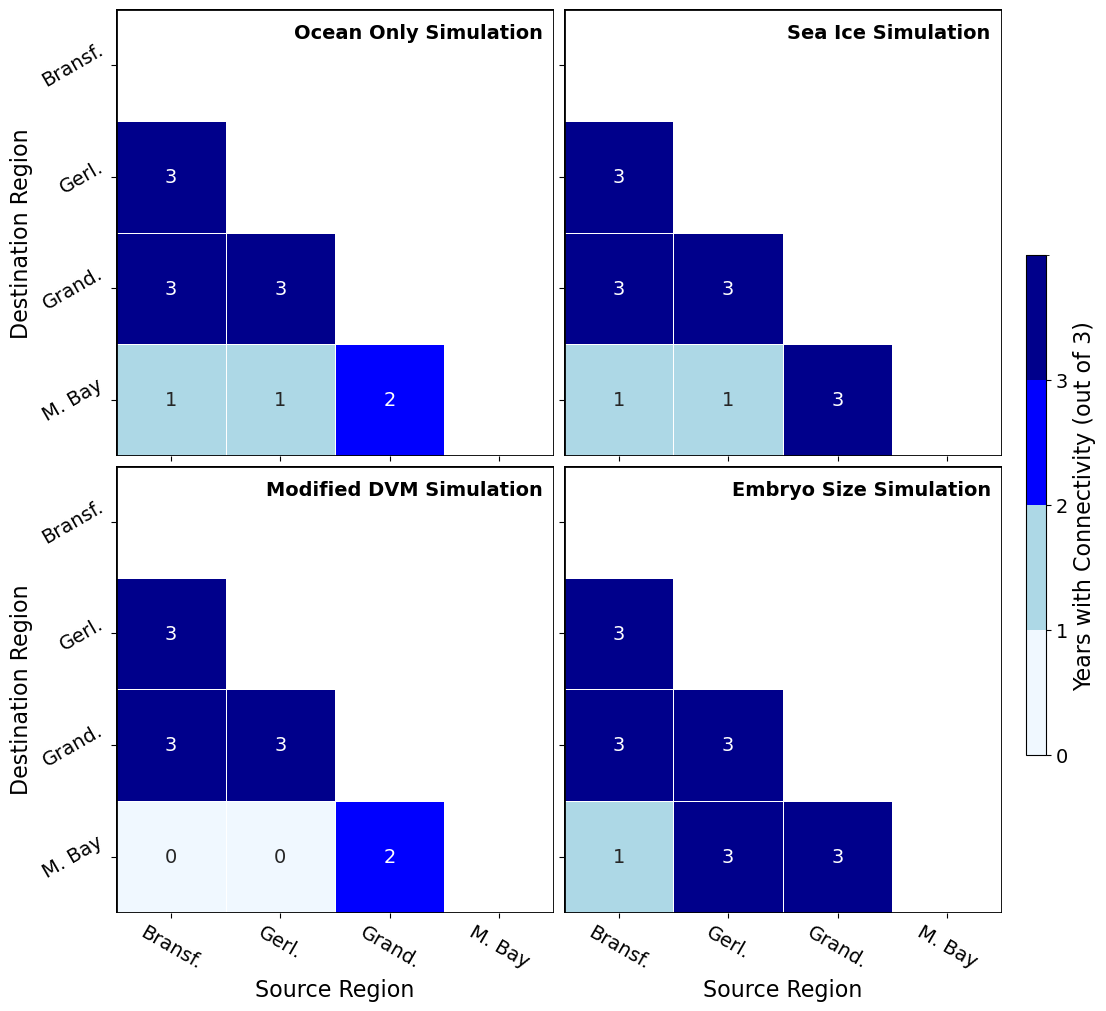

In [51]:
plot_all_hypotheses_grid_anno(
    hypotheses, 
    locations, 
    df_traj, 
    save_path=fig_path+'connectivity_grid_2x2.png'
)

In [52]:
def plot_connect_grid_1x4(hypotheses_dict, locations_dict, df, save_path=None):
    # Extract relevant dictionaries
    hypotheses_name = {key: value['name'] for key, value in hypotheses_dict.items()}
    hypotheses_labels = {key: value['label'] for key, value in hypotheses_dict.items()}
    hypotheses_order = {key: value['order'] for key, value in hypotheses_dict.items()}
    location_labels = {key: value['label_short'] for key, value in locations_dict.items()}
    location_order = {key: value['order'] for key, value in locations_dict.items()}

    # Sort hypotheses by order
    sorted_hypotheses = sorted(hypotheses_name.keys(), key=lambda x: hypotheses_order[x])

    # Update font sizes globally for better scaling
    plt.rcParams.update({
        'font.size': 18,       # General font size
        'axes.titlesize': 14,  # Titles for individual plots
        'axes.labelsize': 16,  # Axis labels
        'xtick.labelsize': 14, # X-tick labels
        'ytick.labelsize': 14  # Y-tick labels
    })

    # Define discrete colormap
    cmap = mcolors.ListedColormap(['aliceblue', 'lightblue', 'blue', 'darkblue'])
    bounds = [0, 1, 2, 3, 4]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)

    # Create a figure with a 1x4 grid and adjust layout
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)
    axes = axes.flatten()

    for i, hypothesis in enumerate(sorted_hypotheses):
        # Compute connectivity matrix
        connectivity_matrix = compute_connectivity_matrix(df, hypothesis)

        # Reorder rows/columns based on location order
        location_keys = sorted(location_labels.keys(), key=lambda x: location_order[x])
        connectivity_matrix = connectivity_matrix.reindex(index=location_keys, columns=location_keys, fill_value=0)

        # Mask upper triangle
        mask = np.triu(np.ones_like(connectivity_matrix, dtype=bool))

        # Plot on the respective subplot
        sns.heatmap(
            connectivity_matrix,
            annot=True,
            fmt=".0f",
            cmap=cmap,
            norm=norm,
            linewidths=.5,
            mask=mask,
            ax=axes[i],
            cbar=False,  # Disable individual color bars
            annot_kws={'fontsize': 14},  # Adjust annotation font size
        )

        # Add annotation in the top right of each plot
        annotation_text = f"{hypotheses_labels[hypothesis]} Simulation"
        axes[i].annotate(
            annotation_text,
            xy=(0.975, 0.925), xycoords='axes fraction',
            fontsize=14, fontweight='bold', ha='right', va='bottom',
            bbox=dict(boxstyle="round, pad=0.3", edgecolor='white', facecolor='white')
        )

        # Add axis labels only where necessary
        if i == 0:  # Only the first column gets Y-axis labels
            axes[i].set_ylabel('Destination Region', fontsize=16)
            axes[i].set_yticklabels([location_labels[loc] for loc in connectivity_matrix.index], rotation=30)
        else:  # Other columns do not have Y-axis labels
            axes[i].set_ylabel('')
            axes[i].set_yticklabels([])

        # All plots should have X-axis labels
        axes[i].set_xlabel('Source Region', fontsize=16)
        axes[i].set_xticklabels([location_labels[loc] for loc in connectivity_matrix.columns], rotation=-30)

        # Add a box around the plot
        rect = patches.Rectangle(
            (0, 0), 1, 1, transform=axes[i].transAxes,
            color='black', linewidth=2, fill=False
        )
        axes[i].add_patch(rect)

    # Add a shared color bar
    cbar_ax = fig.add_axes([1.02, 0.25, 0.02, 0.5])  # Adjust position of the shared color bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax, boundaries=bounds, ticks=[0, 1, 2, 3], label='Years with Connectivity (out of 3)')

    # Save the figure if a path is provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

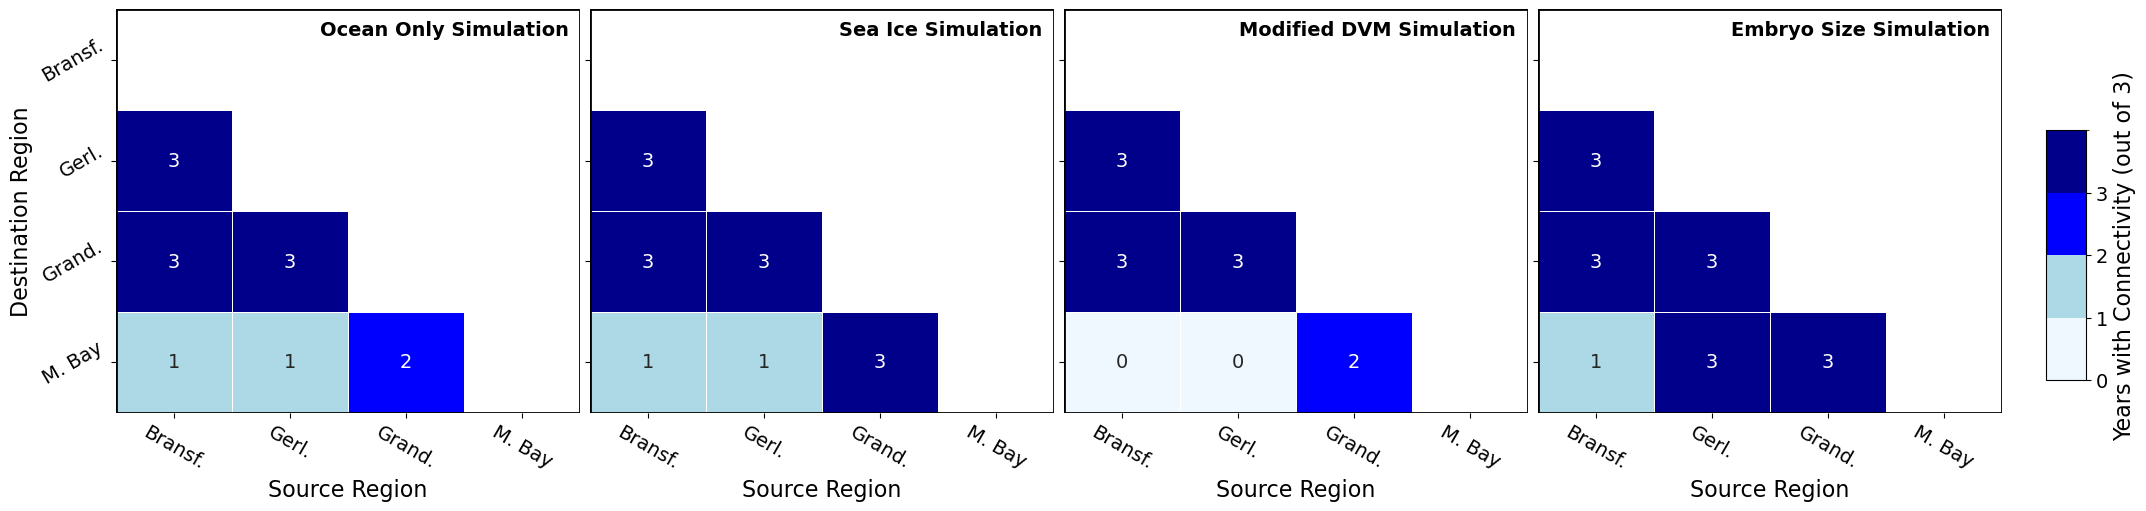

In [53]:
plot_connect_grid_1x4(
    hypotheses, 
    locations, 
    df_traj, 
    save_path=fig_path+'connectivity_grid_1x4.png'
)

In [ ]:
a

# Attempt with h_dvm

In [9]:
# Filter data
h_dvm_data = df_traj[df_traj['hypothesis'] == 'h_dvm']

In [10]:
# Extract starting regions
starting_locations = create_starting_location_df(h_dvm_data)

# Merge trajectories with starting locations
traj_with_start = h_dvm_data.merge(
    starting_locations[['larval_id', 'IDL_loc']],
    on='larval_id',
    suffixes=('', '_source')
)

# Identify destination regions for each particle
destination_regions = ['BS', 'GERL', 'GP', 'MB2']
traj_with_start['destination'] = traj_with_start[destination_regions].idxmax(axis=1)

In [11]:
# Group by source, destination, and year
connectivity_counts = traj_with_start.groupby(['IDL_loc_source', 'destination', 'start_year']).size().reset_index(name='count')

# Convert to a presence indicator (1 if connectivity exists in a year, 0 otherwise)
connectivity_counts['presence'] = connectivity_counts['count'] > 0

# Summarize connectivity over the years
yearly_connectivity = connectivity_counts.groupby(['IDL_loc_source', 'destination'])['presence'].sum().reset_index()
yearly_connectivity.rename(columns={'presence': 'years_connected'}, inplace=True)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [14]:
# Pivot to matrix form
connectivity_matrix = yearly_connectivity.pivot(
    index='destination', 
    columns='IDL_loc_source', 
    values='years_connected'
).fillna(0)


connectivity_matrix

IDL_loc_source,BS,GERL,GP,MB2
destination,,,,
BS,3.0,3.0,3.0,3.0
GERL,3.0,3.0,3.0,0.0
GP,3.0,3.0,3.0,3.0
MB2,0.0,0.0,2.0,3.0


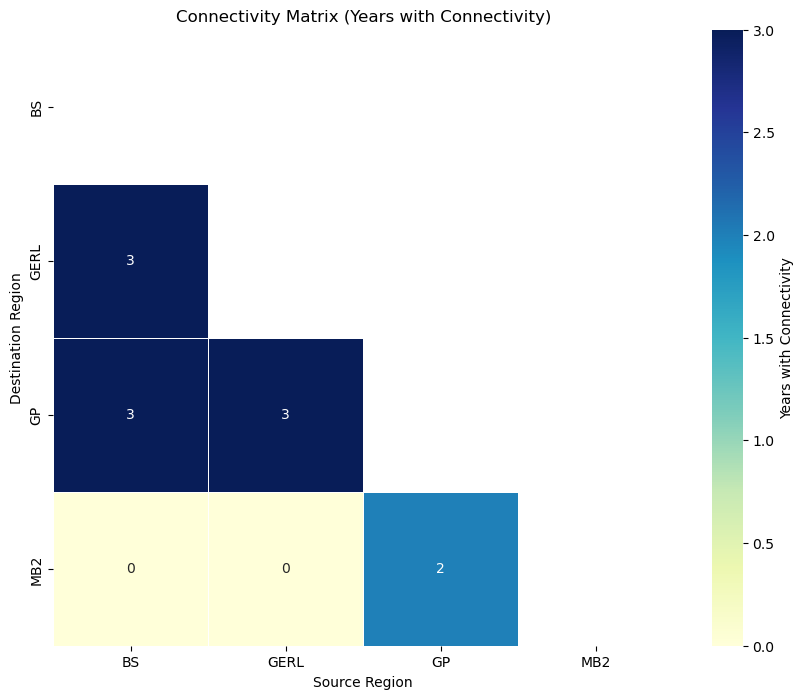

In [15]:

# Create a masked lower triangle
mask = np.triu(np.ones_like(connectivity_matrix, dtype=bool))

# Plot the matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    connectivity_matrix, 
    annot=True, 
    fmt=".0f", 
    cmap="YlGnBu", 
    linewidths=.5, 
    mask=mask, 
    cbar_kws={'label': 'Years with Connectivity'}
)
plt.title('Connectivity Matrix (Years with Connectivity)')
plt.xlabel('Source Region')
plt.ylabel('Destination Region')
plt.show()

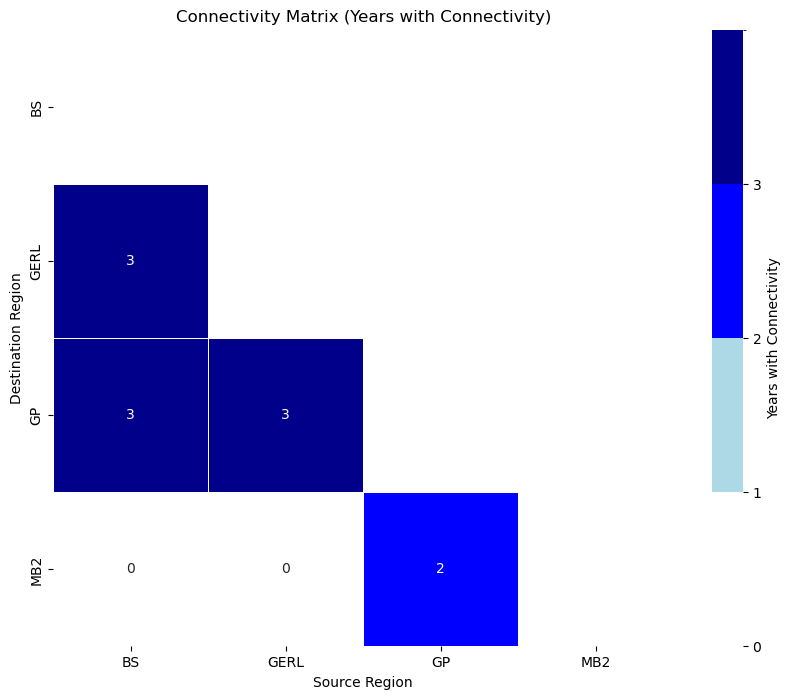

In [16]:
import matplotlib.colors as mcolors

# Define a discrete colormap
cmap = mcolors.ListedColormap(['white', 'lightblue', 'blue', 'darkblue'])
bounds = [0, 1, 2, 3, 4]  # Bounds for each category (0–3 years)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Plot the matrix with discrete colors
plt.figure(figsize=(10, 8))
sns.heatmap(
    connectivity_matrix,
    annot=True,
    fmt=".0f",
    cmap=cmap,
    norm=norm,
    linewidths=.5,
    mask=mask,
    cbar_kws={
        'boundaries': bounds, 
        'ticks': [0, 1, 2, 3], 
        'label': 'Years with Connectivity'
    }
)
plt.title('Connectivity Matrix (Years with Connectivity)')
plt.xlabel('Source Region')
plt.ylabel('Destination Region')
plt.show()

In [ ]:
# Get unique hypotheses
hypotheses = df_traj['hypothesis'].unique()

# Define colormap and normalization for discrete categories
cmap = mcolors.ListedColormap(['white', 'lightblue', 'blue', 'darkblue'])
bounds = [0, 1, 2, 3, 4]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Loop through each hypothesis and plot
for hypothesis in hypotheses:
    # Filter data for the hypothesis
    hypothesis_data = df_traj[df_traj['hypothesis'] == hypothesis]

    # Extract starting locations and connectivity
    starting_locations = create_starting_location_df(hypothesis_data)
    traj_with_start = hypothesis_data.merge(
        starting_locations[['larval_id', 'IDL_loc']],
        on='larval_id',
        suffixes=('', '_source')
    )
    traj_with_start['destination'] = traj_with_start[['BS', 'GERL', 'GP', 'MB2']].idxmax(axis=1)

    # Summarize yearly connectivity
    connectivity_counts = traj_with_start.groupby(['IDL_loc_source', 'destination', 'start_year']).size().reset_index(name='count')
    connectivity_counts['presence'] = connectivity_counts['count'] > 0
    yearly_connectivity = connectivity_counts.groupby(['IDL_loc_source', 'destination'])['presence'].sum().reset_index()
    yearly_connectivity.rename(columns={'presence': 'years_connected'}, inplace=True)

    # Pivot for matrix form
    connectivity_matrix = yearly_connectivity.pivot(
        index='destination',
        columns='IDL_loc_source',
        values='years_connected'
    ).fillna(0)

    # Create mask for upper triangle
    mask = np.triu(np.ones_like(connectivity_matrix, dtype=bool))

    # Plot the matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        connectivity_matrix,
        annot=True,
        fmt=".0f",
        cmap=cmap,
        norm=norm,
        linewidths=.5,
        mask=mask,
        cbar_kws={
            'boundaries': bounds,
            'ticks': [0, 1, 2, 3],
            'label': 'Years with Connectivity'
        }
    )
    plt.title(f'Connectivity Matrix (Years with Connectivity) - {hypothesis}')
    plt.xlabel('Source Region')
    plt.ylabel('Destination Region')
    plt.show()